# Phase 2 — RCM Backscatter Exploration and Stability

This notebook evaluates whether public RCM CEOS-ARD backscatter can separate water from land at Folly Lake and whether a single, explainable rule gives reasonably stable lake-area estimates across the eight available acquisitions.

Folly Lake is used as a feasibility/control site. The analysis does **not** claim environmental change, validated shoreline accuracy, or climate attribution. It uses remote windowed reads only; no full RCM scenes or credentials are stored.

Research questions:

1. Does RR or RL provide better water/land separation?
2. Can one provisional rule be derived from reproducible sample regions?
3. Does that fixed rule remain stable across all comparable dates?
4. How sensitive is estimated area to a small threshold change?


## 1. Imports and constants


In [16]:
from collections import defaultdict, deque

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from matplotlib.patches import Rectangle
from pystac_client import Client
from rasterio.features import bounds as geometry_bounds
from rasterio.features import geometry_mask
from rasterio.plot import plotting_extent
from rasterio.warp import transform_geom
from rasterio.windows import from_bounds
from shapely.geometry import box, mapping

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 90)

STAC_URL = "https://www.eodms-sgdot.nrcan-rncan.gc.ca/search"
ARD_COLLECTION = "rcm-ard"
SEARCH_DATETIME = "2025-01-01T00:00:00Z/2026-10-03T23:59:59Z"

AOI_NAME = "Folly Lake, Colchester County, Nova Scotia"
AOI_BBOX = (-63.575, 45.515, -63.515, 45.565)
SEARCH_CRS = "EPSG:4326"
WORKING_CRS = "EPSG:32620"

# Fixed, reproducible UTM geometries selected by inspecting the Phase 1 RR image.
# The samples are exploratory training evidence, not independent ground truth.
WATER_SAMPLE_BOUNDS = (457220, 5042800, 457340, 5043300)
LAND_SAMPLE_BOUNDS = (457850, 5043250, 457970, 5043900)
ANALYSIS_BOUNDS = (457000, 5041900, 458000, 5044100)
WATER_SAMPLE = box(*WATER_SAMPLE_BOUNDS)
LAND_SAMPLE = box(*LAND_SAMPLE_BOUNDS)
ANALYSIS_ZONE = box(*ANALYSIS_BOUNDS)

REFERENCE_DATE = "2025-07-14"
SENSITIVITY_DB = 1.0

print(f"AOI: {AOI_NAME}")
print(f"Search bbox ({SEARCH_CRS}): {AOI_BBOX}")
print(f"Analysis CRS: {WORKING_CRS}")
print(f"Reference date: {REFERENCE_DATE}")


AOI: Folly Lake, Colchester County, Nova Scotia
Search bbox (EPSG:4326): (-63.575, 45.515, -63.515, 45.565)
Analysis CRS: EPSG:32620
Reference date: 2025-07-14


## 2. Reuse the Phase 1 AOI and discover RCM-ARD observations

The official EODMS STAC endpoint and Phase 1 AOI are reused. Ten catalogue records are expected, but two dates contain overlapping duplicate records from the same satellite/orbit acquisition. They must not be counted as separate observations.


In [17]:
def platform_from_item(item):
    title = item.properties.get("title", "")
    return title.split("_")[0] if title else None


def acquisition_key(item):
    return f"{platform_from_item(item)}-{item.properties.get('sat:absolute_orbit')}"


catalog = Client.open(STAC_URL)
all_items = list(
    catalog.search(
        collections=[ARD_COLLECTION],
        bbox=AOI_BBOX,
        datetime=SEARCH_DATETIME,
        max_items=None,
    ).items()
)
assert all_items, "No public RCM-ARD records were returned."

groups = defaultdict(list)
for item in all_items:
    groups[acquisition_key(item)].append(item)

# Deterministic duplicate handling: all overlapping candidates cover the analysis zone;
# retain the lexicographically first item ID within each satellite/orbit group.
selected_items = []
selected_ids = set()
for key in sorted(groups):
    selected = sorted(groups[key], key=lambda item: item.id)[0]
    selected_items.append(selected)
    selected_ids.add(selected.id)
selected_items.sort(key=lambda item: item.properties["datetime"])

discovery_rows = []
for item in sorted(all_items, key=lambda item: (item.properties["datetime"], item.id)):
    props = item.properties
    discovery_rows.append(
        {
            "acquisition_date": props["datetime"][:10],
            "platform": platform_from_item(item),
            "item_id": item.id,
            "absolute_orbit": props.get("sat:absolute_orbit"),
            "relative_orbit": props.get("sat:relative_orbit"),
            "selected": item.id in selected_ids,
            "note": "retained" if item.id in selected_ids else "duplicate overlapping record",
        }
    )

discovery_df = pd.DataFrame(discovery_rows)
display(discovery_df)
print(f"Catalogue records: {len(all_items)}")
print(f"Independent acquisition groups retained: {len(selected_items)}")
print(f"Duplicate records excluded from temporal counting: {len(all_items) - len(selected_items)}")
assert len(selected_items) == 8


,acquisition_date,platform,item_id,absolute_orbit,relative_orbit,selected,note
0,2025-07-14,RCM3,41d2b89c-cd7a-496b-aaac-8d7326c70728,33172.0,37,True,retained
1,2025-07-26,RCM3,4a51a899-0b2d-41c6-9948-29d7c0dd8ffc,33351.0,37,True,retained
2,2025-09-12,RCM3,8efbb31b-2951-4cb5-8d35-05121f1de930,34067.0,37,True,retained
3,2025-10-14,RCM2,df8f9ed0-f8d6-4043-8ec0-be40128be006,34544.0,37,True,retained
4,2025-10-26,RCM2,156a9cbb-70dc-4071-a663-d48150390185,34723.0,37,False,duplicate overlapping record
5,2025-10-26,RCM2,131e7580-fdb3-4897-b374-e4fc8330141c,34723.0,37,True,retained
6,2025-11-07,RCM2,bc3da71c-0686-4254-921a-5f9ecbbc149a,34902.0,37,False,duplicate overlapping record
7,2025-11-07,RCM2,73a52ca6-f8ac-4d82-a81b-08a23084460a,34902.0,37,True,retained
8,2026-07-05,RCM2,4b387ee1-5623-46e6-8001-811d4074986b,38482.0,37,True,retained
9,2026-08-02,RCM3,d5d2c686-1c84-4304-83fd-4db5d9a9a8d8,38900.0,37,True,retained


Catalogue records: 10
Independent acquisition groups retained: 8
Duplicate records excluded from temporal counting: 2


## 3. Load comparable RR, RL, and local-incidence-angle windows

Each selected item is read over the same fixed analysis rectangle. RR and RL are converted from positive linear backscatter to dB using `10 × log10(value)`. Local incidence angle remains in degrees. The code verifies the CRS, 20 m grid, shape, and grid transform rather than assuming alignment.


In [18]:
def read_asset_window(item, asset_key, geometry=ANALYSIS_ZONE):
    asset = item.assets[asset_key]
    with rasterio.Env(
        GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR",
        CPL_VSIL_CURL_ALLOWED_EXTENSIONS=".tif",
    ):
        with rasterio.open(asset.href) as src:
            transformed_geometry = transform_geom(WORKING_CRS, src.crs, mapping(geometry))
            window = from_bounds(
                *geometry_bounds(transformed_geometry), transform=src.transform
            ).round_offsets().round_lengths()
            source = src.read(1, window=window, masked=True)
            window_transform = src.window_transform(window)
            inside = geometry_mask(
                [transformed_geometry],
                out_shape=source.shape,
                transform=window_transform,
                invert=True,
            )
            values = source.filled(np.nan).astype("float64")
            valid = inside & (~np.ma.getmaskarray(source)) & np.isfinite(values)
            result = np.ma.array(values, mask=~valid)
            return {
                "array": result,
                "transform": window_transform,
                "crs": str(src.crs),
                "res": src.res,
                "nodata": src.nodata,
                "driver": src.driver,
            }


def linear_to_db(array):
    linear = array.filled(np.nan)
    valid = (~np.ma.getmaskarray(array)) & np.isfinite(linear) & (linear > 0)
    db = np.full(array.shape, np.nan, dtype="float64")
    db[valid] = 10.0 * np.log10(linear[valid])
    return np.ma.array(db, mask=~valid)


scenes = {}
metadata_rows = []
for item in selected_items:
    date = item.properties["datetime"][:10]
    rr = read_asset_window(item, "rr")
    rl = read_asset_window(item, "rl")
    lia = read_asset_window(item, "local_inc_angle")

    assert rr["crs"] == rl["crs"] == lia["crs"]
    assert rr["res"] == rl["res"] == lia["res"]
    assert rr["array"].shape == rl["array"].shape == lia["array"].shape
    assert rr["transform"] == rl["transform"] == lia["transform"]

    scenes[date] = {
        "item": item,
        "rr_db": linear_to_db(rr["array"]),
        "rl_db": linear_to_db(rl["array"]),
        "lia": lia["array"],
        "transform": rr["transform"],
        "crs": rr["crs"],
        "res": rr["res"],
        "extent": plotting_extent(rr["array"], rr["transform"]),
    }

reference_grid = (
    scenes[REFERENCE_DATE]["crs"],
    scenes[REFERENCE_DATE]["res"],
    scenes[REFERENCE_DATE]["transform"],
    scenes[REFERENCE_DATE]["rr_db"].shape,
)

for date, scene in scenes.items():
    item = scene["item"]
    props = item.properties
    grid = (scene["crs"], scene["res"], scene["transform"], scene["rr_db"].shape)
    lia_values = scene["lia"].compressed()
    metadata_rows.append(
        {
            "date": date,
            "platform": platform_from_item(item),
            "item_id": item.id,
            "product_type": props.get("sar:product_type"),
            "instrument_mode": props.get("sar:instrument_mode"),
            "polarizations": ", ".join(props.get("sar:polarizations", [])),
            "orbit_state": props.get("sat:orbit_state"),
            "look_direction": props.get("sar:observation_direction"),
            "relative_orbit": props.get("sat:relative_orbit"),
            "processing_level": props.get("processing:level"),
            "crs": scene["crs"],
            "pixel_spacing_m": scene["res"][0],
            "grid_matches_reference": grid == reference_grid,
            "local_incidence_mean_deg": lia_values.mean(),
            "local_incidence_min_deg": lia_values.min(),
            "local_incidence_max_deg": lia_values.max(),
            "rr_valid_pixels": scene["rr_db"].count(),
            "rl_valid_pixels": scene["rl_db"].count(),
        }
    )

metadata_df = pd.DataFrame(metadata_rows)
display(metadata_df.round(3))

assert metadata_df["grid_matches_reference"].all()
assert metadata_df["crs"].eq("EPSG:32620").all()
assert metadata_df["pixel_spacing_m"].eq(20.0).all()
assert metadata_df[["rr_valid_pixels", "rl_valid_pixels"]].gt(0).all().all()
print("All eight selected RR/RL windows opened successfully and share the tested grid.")


,date,platform,item_id,product_type,instrument_mode,polarizations,orbit_state,look_direction,relative_orbit,processing_level,crs,pixel_spacing_m,grid_matches_reference,local_incidence_mean_deg,local_incidence_min_deg,local_incidence_max_deg,rr_valid_pixels,rl_valid_pixels
0,2025-07-14,RCM3,41d2b89c-cd7a-496b-aaac-8d7326c70728,MLC,Medium Resolution 30m,"CH, CV, XC",Descending,Right,37,l2,EPSG:32620,20.0,True,27.975,5.228,50.650,5500,5500
1,2025-07-26,RCM3,4a51a899-0b2d-41c6-9948-29d7c0dd8ffc,MLC,Medium Resolution 30m,"CH, CV, XC",Descending,Right,37,l2,EPSG:32620,20.0,True,27.982,5.103,50.556,5500,5500
2,2025-09-12,RCM3,8efbb31b-2951-4cb5-8d35-05121f1de930,MLC,Medium Resolution 30m,"CH, CV, XC",Descending,Right,37,l2,EPSG:32620,20.0,True,27.971,5.226,50.647,5500,5500
3,2025-10-14,RCM2,df8f9ed0-f8d6-4043-8ec0-be40128be006,MLC,Medium Resolution 30m,"CH, CV, XC",Descending,Right,37,l2,EPSG:32620,20.0,True,27.985,5.105,50.560,5500,5500
4,2025-10-26,RCM2,131e7580-fdb3-4897-b374-e4fc8330141c,MLC,Medium Resolution 30m,"CH, CV, XC",Descending,Right,37,l2,EPSG:32620,20.0,True,27.981,5.103,50.556,5500,5500
5,2025-11-07,RCM2,73a52ca6-f8ac-4d82-a81b-08a23084460a,MLC,Medium Resolution 30m,"CH, CV, XC",Descending,Right,37,l2,EPSG:32620,20.0,True,27.980,5.102,50.554,5500,5500
6,2026-07-05,RCM2,4b387ee1-5623-46e6-8001-811d4074986b,MLC,Medium Resolution 30m,"CH, CV, XC",Descending,Right,37,l2,EPSG:32620,20.0,True,27.980,4.919,50.074,5500,5500
7,2026-08-02,RCM3,d5d2c686-1c84-4304-83fd-4db5d9a9a8d8,MLC,Medium Resolution 30m,"CH, CV, XC",Descending,Right,37,l2,EPSG:32620,20.0,True,27.984,4.921,50.078,5500,5500


All eight selected RR/RL windows opened successfully and share the tested grid.


## 4. Acquisition comparability

All eight retained acquisitions are Level-2 MLC / CEOS ARD NRB-POL, `Medium Resolution 30m`, relative orbit 37, descending/right-looking, EPSG:32620, and 20 m output spacing. Their fixed analysis windows share an identical pixel grid. Mean local incidence angle differs by only about 0.01° across dates.

The dates use both RCM-2 and RCM-3, so platform remains a potential confounder. Matching metadata and grids support this feasibility comparison, but they do not prove perfect radiometric equivalence or replace Phase 3 preprocessing checks.


## 5. Reproducible water and land samples

The water sample is a small rectangle well inside the western lake lobe. The land sample is a separate rectangle east of the visible shoreline. Both are fixed in EPSG:32620 and avoid the shoreline as far as the 20 m grid allows. The larger analysis rectangle bounds the connected-component search.

These regions were selected from the reference SAR image and are **not ground-truth polygons**.


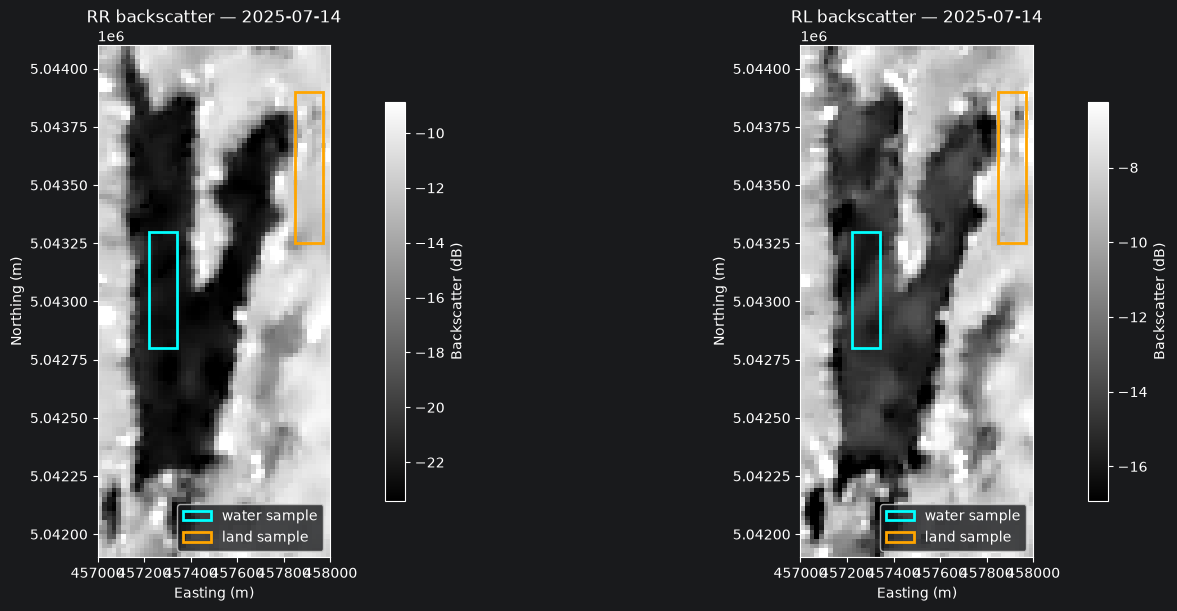

In [19]:
reference_scene = scenes[REFERENCE_DATE]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
for ax, asset_key, title in zip(axes, ("rr_db", "rl_db"), ("RR", "RL")):
    image = reference_scene[asset_key]
    display_min, display_max = np.percentile(image.compressed(), [2, 98])
    artist = ax.imshow(
        image,
        cmap="gray",
        vmin=display_min,
        vmax=display_max,
        extent=reference_scene["extent"],
    )
    for bounds, color, label in (
        (WATER_SAMPLE_BOUNDS, "cyan", "water sample"),
        (LAND_SAMPLE_BOUNDS, "orange", "land sample"),
    ):
        left, bottom, right, top = bounds
        ax.add_patch(
            Rectangle(
                (left, bottom), right - left, top - bottom,
                fill=False, edgecolor=color, linewidth=2, label=label,
            )
        )
    ax.set_title(f"{title} backscatter — {REFERENCE_DATE}")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.legend(loc="lower right")
    fig.colorbar(artist, ax=ax, label="Backscatter (dB)", shrink=0.78)
plt.show()


## 6. RR and RL water/land distribution analysis


In [20]:
def mask_for_geometry(scene, geometry):
    transformed = transform_geom(WORKING_CRS, scene["crs"], mapping(geometry))
    return geometry_mask(
        [transformed],
        out_shape=scene["rr_db"].shape,
        transform=scene["transform"],
        invert=True,
    )


def describe(values):
    return {
        "count": int(values.size),
        "mean_db": float(np.mean(values)),
        "median_db": float(np.median(values)),
        "std_db": float(np.std(values, ddof=1)),
        "q1_db": float(np.percentile(values, 25)),
        "q3_db": float(np.percentile(values, 75)),
    }


sample_rows = []
sample_values = {}
for date, scene in scenes.items():
    water_mask = mask_for_geometry(scene, WATER_SAMPLE)
    land_mask = mask_for_geometry(scene, LAND_SAMPLE)
    for asset_name in ("RR", "RL"):
        image = scene[f"{asset_name.lower()}_db"]
        valid = ~np.ma.getmaskarray(image)
        water_values = image.data[water_mask & valid]
        land_values = image.data[land_mask & valid]
        sample_values[(date, asset_name, "water")] = water_values
        sample_values[(date, asset_name, "land")] = land_values
        water = describe(water_values)
        land = describe(land_values)
        pooled_std = np.sqrt((water["std_db"] ** 2 + land["std_db"] ** 2) / 2.0)
        sample_rows.append(
            {
                "date": date,
                "platform": platform_from_item(scene["item"]),
                "asset": asset_name,
                **{f"water_{key}": value for key, value in water.items()},
                **{f"land_{key}": value for key, value in land.items()},
                "median_gap_db": land["median_db"] - water["median_db"],
                "standardized_separation": (land["mean_db"] - water["mean_db"]) / pooled_std,
            }
        )

sample_stats_df = pd.DataFrame(sample_rows)
display(sample_stats_df.round(3))


,date,platform,asset,water_count,water_mean_db,water_median_db,water_std_db,water_q1_db,water_q3_db,land_count,land_mean_db,land_median_db,land_std_db,land_q1_db,land_q3_db,median_gap_db,standardized_separation
0,2025-07-14,RCM3,RR,150,-22.511,-22.511,0.391,-22.727,-22.288,192,-11.774,-11.743,1.071,-12.340,-11.273,10.768,13.315
1,2025-07-14,RCM3,RL,150,-15.135,-15.236,0.759,-15.820,-14.520,192,-8.246,-8.291,1.257,-8.866,-7.664,6.945,6.634
2,2025-07-26,RCM3,RR,150,-22.468,-22.359,0.503,-22.665,-22.169,192,-11.373,-11.290,0.846,-11.887,-10.760,11.069,15.945
3,2025-07-26,RCM3,RL,150,-14.790,-14.895,0.513,-15.152,-14.479,192,-8.215,-8.150,0.850,-8.606,-7.696,6.744,9.370
4,2025-09-12,RCM3,RR,150,-22.688,-22.652,0.679,-22.903,-22.330,192,-11.617,-11.660,0.786,-11.996,-11.264,10.992,15.070
5,2025-09-12,RCM3,RL,150,-13.390,-13.339,0.728,-13.829,-12.930,192,-9.046,-8.928,0.921,-9.764,-8.250,4.412,5.231
6,2025-10-14,RCM2,RR,150,-23.866,-23.806,0.492,-24.087,-23.569,192,-10.220,-10.200,0.919,-10.812,-9.757,13.606,18.511
7,2025-10-14,RCM2,RL,150,-23.011,-23.051,0.780,-23.529,-22.647,192,-8.949,-9.124,0.961,-9.665,-8.266,13.927,16.064
8,2025-10-26,RCM2,RR,150,-23.583,-23.644,0.515,-24.031,-23.116,192,-9.569,-9.696,1.048,-10.171,-9.079,13.948,16.972
9,2025-10-26,RCM2,RL,150,-23.063,-23.142,0.385,-23.345,-22.801,192,-8.310,-8.501,1.277,-8.927,-7.912,14.641,15.639


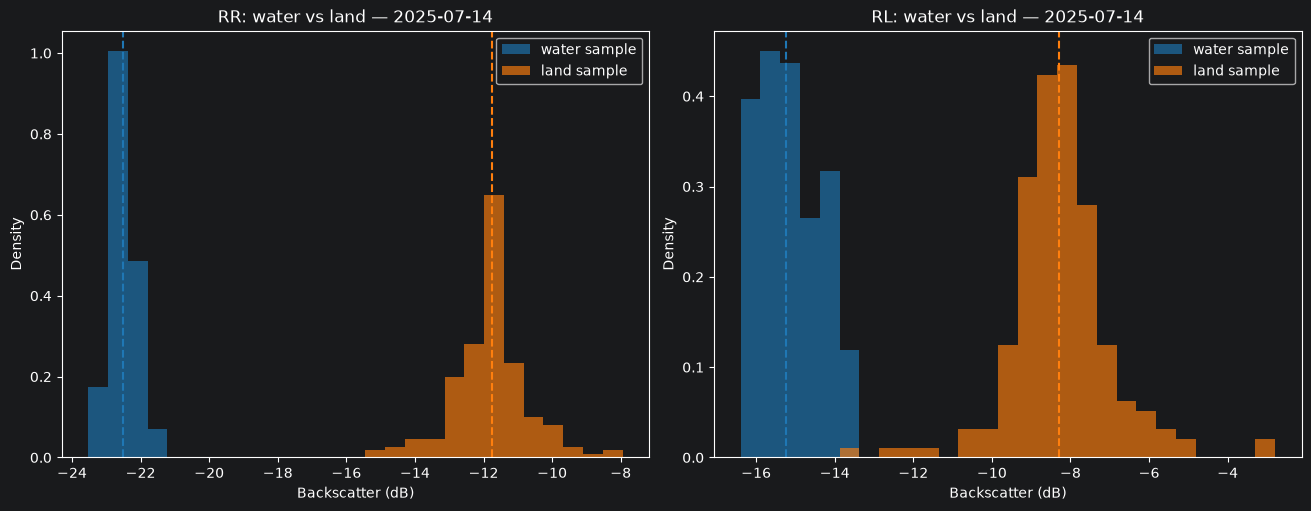

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, asset_name in zip(axes, ("RR", "RL")):
    water_values = sample_values[(REFERENCE_DATE, asset_name, "water")]
    land_values = sample_values[(REFERENCE_DATE, asset_name, "land")]
    bins = np.linspace(min(water_values.min(), land_values.min()), max(water_values.max(), land_values.max()), 28)
    ax.hist(water_values, bins=bins, alpha=0.65, density=True, label="water sample", color="tab:blue")
    ax.hist(land_values, bins=bins, alpha=0.65, density=True, label="land sample", color="tab:orange")
    ax.axvline(np.median(water_values), color="tab:blue", linestyle="--")
    ax.axvline(np.median(land_values), color="tab:orange", linestyle="--")
    ax.set_title(f"{asset_name}: water vs land — {REFERENCE_DATE}")
    ax.set_xlabel("Backscatter (dB)")
    ax.set_ylabel("Density")
    ax.legend()
plt.show()


## 7. Provisional candidate thresholds

For each asset, the reference-date threshold is the midpoint between the water sample's upper quartile and the land sample's lower quartile:

`threshold = (water Q3 + land Q1) / 2`

This uses the observed separation gap and avoids choosing an unexplained round number. A pixel below the threshold is a water candidate. Thresholds are provisional and are not accuracy-validated.


In [22]:
thresholds = {}
separation_rows = []
reference_stats = sample_stats_df[sample_stats_df["date"].eq(REFERENCE_DATE)].set_index("asset")
for asset_name in ("RR", "RL"):
    row = reference_stats.loc[asset_name]
    threshold = (row["water_q3_db"] + row["land_q1_db"]) / 2.0
    thresholds[asset_name] = float(threshold)
    separation_rows.append(
        {
            "asset": asset_name,
            "water_median_db": row["water_median_db"],
            "land_median_db": row["land_median_db"],
            "median_gap_db": row["median_gap_db"],
            "standardized_separation": row["standardized_separation"],
            "provisional_threshold_db": threshold,
        }
    )

separation_df = pd.DataFrame(separation_rows)
display(separation_df.round(3))
print(f"RR candidate threshold: {thresholds['RR']:.3f} dB")
print(f"RL candidate threshold: {thresholds['RL']:.3f} dB")


,asset,water_median_db,land_median_db,median_gap_db,standardized_separation,provisional_threshold_db
0,RR,-22.511,-11.743,10.768,13.315,-17.314
1,RL,-15.236,-8.291,6.945,6.634,-11.693


RR candidate threshold: -17.314 dB
RL candidate threshold: -11.693 dB


## 8. Classification rule and reference-date water mask

The explainable rule has two parts:

1. mark valid pixels below the fixed asset threshold;
2. retain only 8-connected thresholded components that intersect the fixed interior-water sample.

The seeded connectivity step suppresses unrelated dark patches elsewhere in the analysis rectangle. It also makes the estimate dependent on lake connectivity, so it remains a provisional measurement rule.


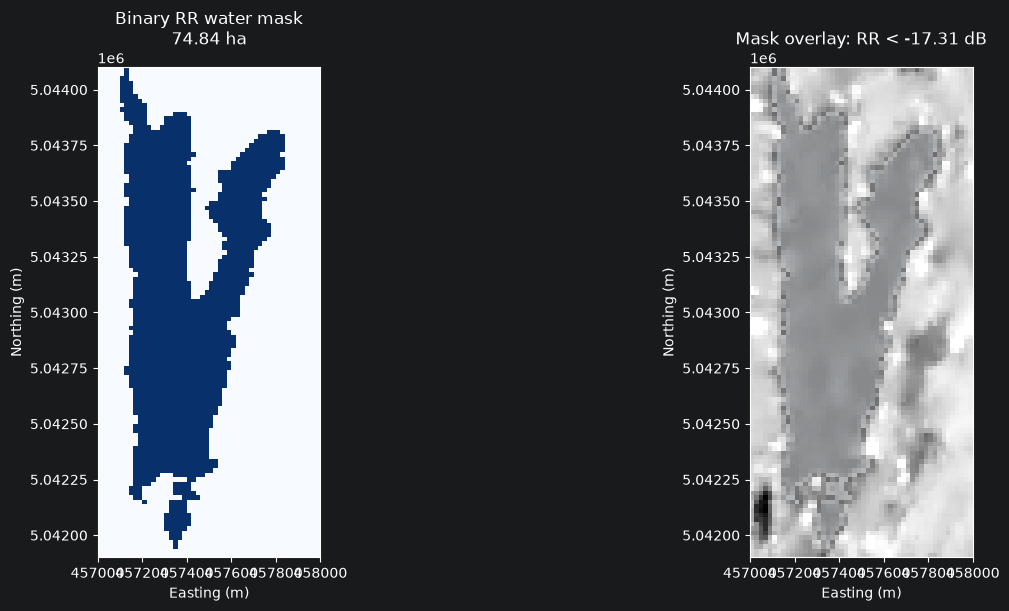

Reference-date RR water pixels: 1,871
Reference-date estimated water area: 74.84 ha


In [23]:
def seeded_components(binary_mask, seed_mask):
    rows, cols = binary_mask.shape
    visited = np.zeros_like(binary_mask, dtype=bool)
    selected = np.zeros_like(binary_mask, dtype=bool)
    neighbours = [
        (-1, -1), (-1, 0), (-1, 1),
        (0, -1),            (0, 1),
        (1, -1),  (1, 0),  (1, 1),
    ]
    for row, col in np.argwhere(binary_mask & seed_mask):
        row, col = int(row), int(col)
        if visited[row, col]:
            continue
        queue = deque([(row, col)])
        component = []
        touches_seed = False
        visited[row, col] = True
        while queue:
            current_row, current_col = queue.popleft()
            component.append((current_row, current_col))
            touches_seed |= bool(seed_mask[current_row, current_col])
            for row_offset, col_offset in neighbours:
                next_row = current_row + row_offset
                next_col = current_col + col_offset
                if (
                    0 <= next_row < rows
                    and 0 <= next_col < cols
                    and binary_mask[next_row, next_col]
                    and not visited[next_row, next_col]
                ):
                    visited[next_row, next_col] = True
                    queue.append((next_row, next_col))
        if touches_seed:
            for component_row, component_col in component:
                selected[component_row, component_col] = True
    return selected


def classify_scene(scene, asset_name, threshold_db):
    image = scene[f"{asset_name.lower()}_db"]
    valid = ~np.ma.getmaskarray(image)
    seed_mask = mask_for_geometry(scene, WATER_SAMPLE)
    candidates = valid & (image.data < threshold_db)
    return seeded_components(candidates, seed_mask)


reference_rr_mask = classify_scene(reference_scene, "RR", thresholds["RR"])
pixel_area_ha = abs(reference_scene["res"][0] * reference_scene["res"][1]) / 10_000.0
reference_area_ha = reference_rr_mask.sum() * pixel_area_ha

fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
rr_image = reference_scene["rr_db"]
display_min, display_max = np.percentile(rr_image.compressed(), [2, 98])
axes[0].imshow(reference_rr_mask, cmap="Blues", extent=reference_scene["extent"])
axes[0].set_title(f"Binary RR water mask\n{reference_area_ha:.2f} ha")
axes[1].imshow(rr_image, cmap="gray", vmin=display_min, vmax=display_max, extent=reference_scene["extent"])
axes[1].imshow(
    np.ma.masked_where(~reference_rr_mask, reference_rr_mask),
    cmap="Blues", alpha=0.55, extent=reference_scene["extent"],
)
axes[1].set_title(f"Mask overlay: RR < {thresholds['RR']:.2f} dB")
for ax in axes:
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
plt.show()

print(f"Reference-date RR water pixels: {reference_rr_mask.sum():,}")
print(f"Reference-date estimated water area: {reference_area_ha:.2f} ha")


## 9. Apply the same RR and RL rules across all dates


In [24]:
area_rows = []
for date, scene in scenes.items():
    row = {
        "date": pd.Timestamp(date),
        "platform": platform_from_item(scene["item"]),
        "item_id": scene["item"].id,
    }
    for asset_name in ("RR", "RL"):
        water_mask = classify_scene(scene, asset_name, thresholds[asset_name])
        scene[f"{asset_name.lower()}_mask"] = water_mask
        row[f"{asset_name.lower()}_water_pixels"] = int(water_mask.sum())
        row[f"{asset_name.lower()}_area_ha"] = float(water_mask.sum() * pixel_area_ha)
    area_rows.append(row)

area_df = pd.DataFrame(area_rows).sort_values("date").reset_index(drop=True)
for asset_name in ("RR", "RL"):
    column = f"{asset_name.lower()}_area_ha"
    median_area = area_df[column].median()
    area_df[f"{asset_name.lower()}_difference_from_median_ha"] = area_df[column] - median_area
    area_df[f"{asset_name.lower()}_difference_from_median_pct"] = 100.0 * (
        area_df[column] - median_area
    ) / median_area

display(area_df.round(3))


/var/folders/fz/c0zrt59s5x7ggbk5hw3hrzbw0000gn/T/ipykernel_27417/2834347514.py:24: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(area_df.round(3))


,date,platform,item_id,rr_water_pixels,rr_area_ha,rl_water_pixels,rl_area_ha,rr_difference_from_median_ha,rr_difference_from_median_pct,rl_difference_from_median_ha,rl_difference_from_median_pct
0,2025-07-14,RCM3,41d2b89c-cd7a-496b-aaac-8d7326c70728,1871,74.84,2071,82.84,4.08,5.766,1.58,1.944
1,2025-07-26,RCM3,4a51a899-0b2d-41c6-9948-29d7c0dd8ffc,1761,70.44,1984,79.36,-0.32,-0.452,-1.90,-2.338
2,2025-09-12,RCM3,8efbb31b-2951-4cb5-8d35-05121f1de930,1777,71.08,1757,70.28,0.32,0.452,-10.98,-13.512
3,2025-10-14,RCM2,df8f9ed0-f8d6-4043-8ec0-be40128be006,1753,70.12,2048,81.92,-0.64,-0.904,0.66,0.812
4,2025-10-26,RCM2,131e7580-fdb3-4897-b374-e4fc8330141c,1757,70.28,2016,80.64,-0.48,-0.678,-0.62,-0.763
5,2025-11-07,RCM2,73a52ca6-f8ac-4d82-a81b-08a23084460a,1870,74.80,1882,75.28,4.04,5.709,-5.98,-7.359
6,2026-07-05,RCM2,4b387ee1-5623-46e6-8001-811d4074986b,1873,74.92,2047,81.88,4.16,5.879,0.62,0.763
7,2026-08-02,RCM3,d5d2c686-1c84-4304-83fd-4db5d9a9a8d8,1756,70.24,2066,82.64,-0.52,-0.735,1.38,1.698


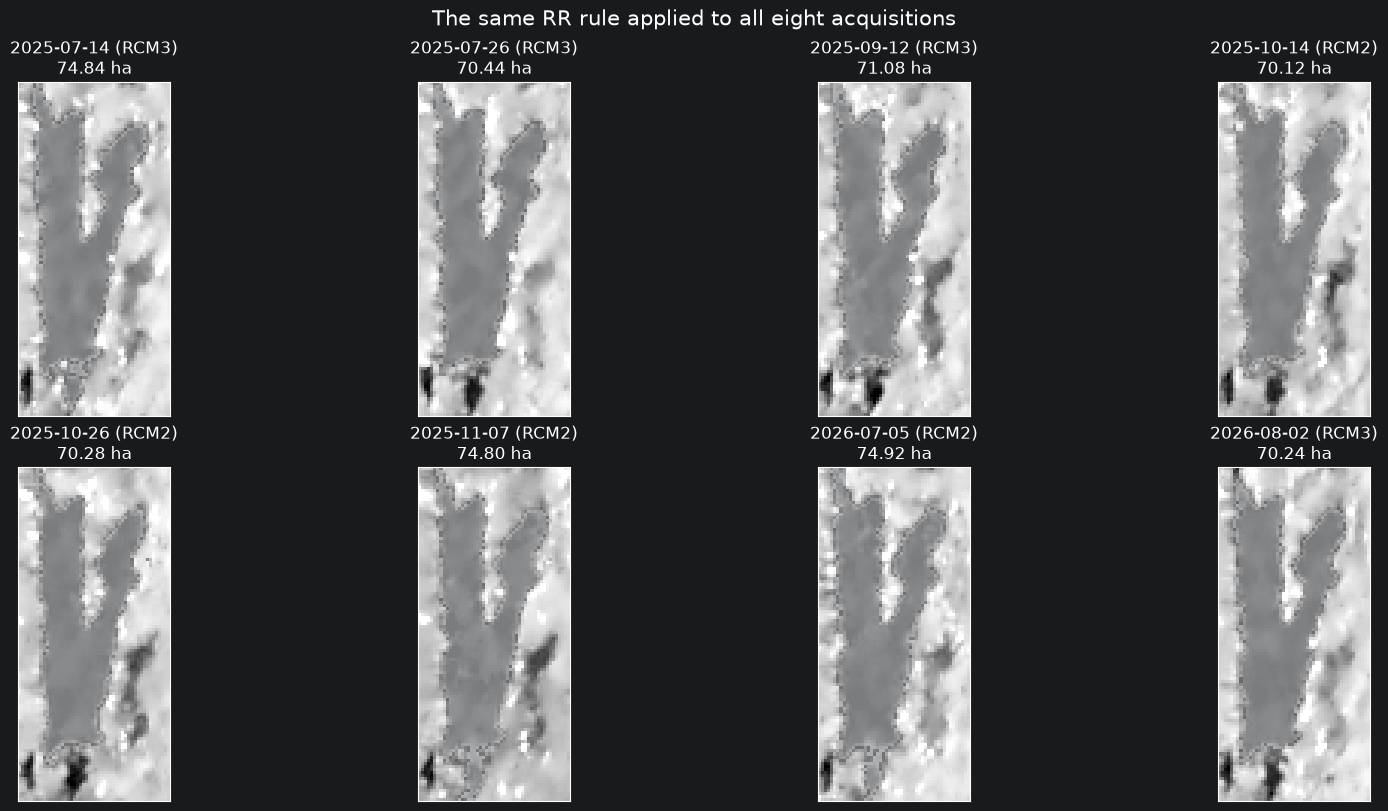

In [25]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)
for ax, (date, scene) in zip(axes.flat, scenes.items()):
    image = scene["rr_db"]
    display_min, display_max = np.percentile(image.compressed(), [2, 98])
    ax.imshow(image, cmap="gray", vmin=display_min, vmax=display_max, extent=scene["extent"])
    ax.imshow(
        np.ma.masked_where(~scene["rr_mask"], scene["rr_mask"]),
        cmap="Blues", alpha=0.50, extent=scene["extent"],
    )
    area = area_df.loc[area_df["date"].eq(pd.Timestamp(date)), "rr_area_ha"].iloc[0]
    ax.set_title(f"{date} ({platform_from_item(scene['item'])})\n{area:.2f} ha")
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("The same RR rule applied to all eight acquisitions", fontsize=15)
plt.show()


## 10. Temporal stability and RR/RL comparison


,asset,threshold_db,median_area_ha,mean_area_ha,std_area_ha,coefficient_of_variation_pct,minimum_area_ha,maximum_area_ha,range_relative_to_median_pct,largest_deviation_date,largest_abs_deviation_ha,largest_abs_deviation_pct
0,RR,-17.314,70.76,72.090,2.306,3.199,70.12,74.92,6.783,2026-07-05,4.16,5.879
1,RL,-11.693,81.26,79.355,4.416,5.565,70.28,82.84,15.457,2025-09-12,10.98,13.512


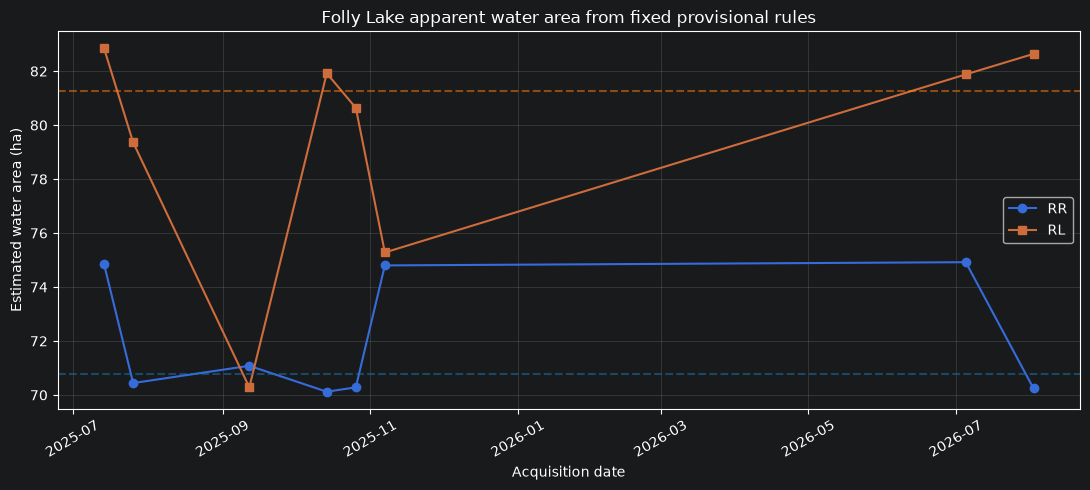

In [26]:
stability_rows = []
for asset_name in ("RR", "RL"):
    values = area_df[f"{asset_name.lower()}_area_ha"]
    median = float(values.median())
    mean = float(values.mean())
    std = float(values.std(ddof=1))
    deviations_pct = 100.0 * (values - median) / median
    outlier_index = deviations_pct.abs().idxmax()
    stability_rows.append(
        {
            "asset": asset_name,
            "threshold_db": thresholds[asset_name],
            "median_area_ha": median,
            "mean_area_ha": mean,
            "std_area_ha": std,
            "coefficient_of_variation_pct": 100.0 * std / mean,
            "minimum_area_ha": float(values.min()),
            "maximum_area_ha": float(values.max()),
            "range_relative_to_median_pct": 100.0 * (values.max() - values.min()) / median,
            "largest_deviation_date": area_df.loc[outlier_index, "date"].date().isoformat(),
            "largest_abs_deviation_ha": float((values - median).abs().max()),
            "largest_abs_deviation_pct": float(deviations_pct.abs().max()),
        }
    )

stability_df = pd.DataFrame(stability_rows)
display(stability_df.round(3))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(area_df["date"], area_df["rr_area_ha"], marker="o", label="RR")
ax.plot(area_df["date"], area_df["rl_area_ha"], marker="s", label="RL")
ax.axhline(area_df["rr_area_ha"].median(), color="tab:blue", linestyle="--", alpha=0.5)
ax.axhline(area_df["rl_area_ha"].median(), color="tab:orange", linestyle="--", alpha=0.5)
ax.set_title("Folly Lake apparent water area from fixed provisional rules")
ax.set_xlabel("Acquisition date")
ax.set_ylabel("Estimated water area (ha)")
ax.grid(alpha=0.25)
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 11. Threshold sensitivity

The chosen RR threshold is perturbed by ±1 dB. A more negative threshold is stricter and produces less water; a less negative threshold is more permissive. The test reports sensitivity without tuning the threshold to minimize temporal variation.


,threshold_delta_db,threshold_db,median_area_ha,mean_area_ha,std_area_ha,minimum_area_ha,maximum_area_ha,range_ha
0,-1.0,-18.314,68.32,69.005,1.369,67.92,71.84,3.92
1,0.0,-17.314,70.76,72.090,2.306,70.12,74.92,4.80
2,1.0,-16.314,76.68,76.810,1.271,75.48,78.60,3.12


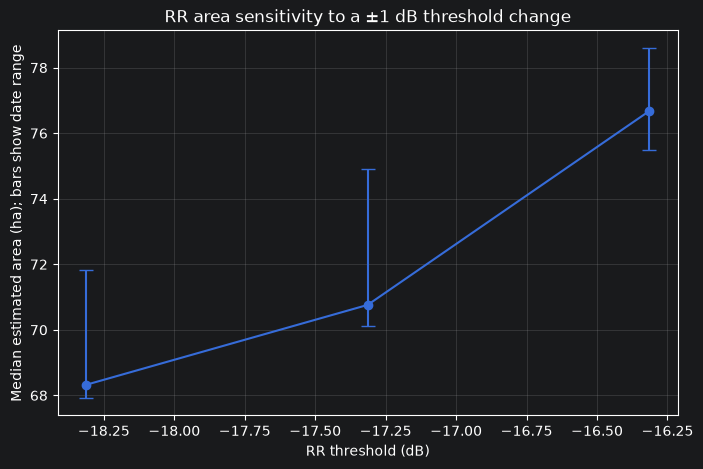

In [27]:
sensitivity_rows = []
for delta_db in (-SENSITIVITY_DB, 0.0, SENSITIVITY_DB):
    threshold = thresholds["RR"] + delta_db
    areas = []
    for date, scene in scenes.items():
        mask = classify_scene(scene, "RR", threshold)
        areas.append(mask.sum() * pixel_area_ha)
    values = pd.Series(areas, dtype="float64")
    sensitivity_rows.append(
        {
            "threshold_delta_db": delta_db,
            "threshold_db": threshold,
            "median_area_ha": values.median(),
            "mean_area_ha": values.mean(),
            "std_area_ha": values.std(ddof=1),
            "minimum_area_ha": values.min(),
            "maximum_area_ha": values.max(),
            "range_ha": values.max() - values.min(),
        }
    )

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    sensitivity_df["threshold_db"],
    sensitivity_df["median_area_ha"],
    yerr=[
        sensitivity_df["median_area_ha"] - sensitivity_df["minimum_area_ha"],
        sensitivity_df["maximum_area_ha"] - sensitivity_df["median_area_ha"],
    ],
    marker="o", capsize=5,
)
ax.set_title("RR area sensitivity to a ±1 dB threshold change")
ax.set_xlabel("RR threshold (dB)")
ax.set_ylabel("Median estimated area (ha); bars show date range")
ax.grid(alpha=0.25)
plt.show()


## 12. Findings

Snapshot confirmed on **2026-10-03**:

- All eight dates were retained as the comparable acquisition subset. All share relative orbit 37, descending/right-looking geometry, Level-2 MLC NRB-POL processing, EPSG:32620, 20 m spacing, and a common tested grid. Two overlapping catalogue records were removed as duplicates, not as bad dates.
- On the 2025-07-14 reference date, RR gives a **10.77 dB median water/land gap** and a **13.32 standardized separation**. RL gives a **6.95 dB median gap** and **6.63 standardized separation**.
- The provisional quartile-gap thresholds are **RR < -17.31 dB** and **RL < -11.69 dB**, followed by seeded 8-connected component selection.
- RR is currently the more useful asset. Its eight-date median area is **70.76 ha**, mean **72.09 ha**, standard deviation **2.31 ha**, and coefficient of variation **3.20%**. The range is **70.12–74.92 ha**; the largest absolute deviation from the median is **4.16 ha (5.88%)** on 2026-07-05.
- RL is less stable: median **81.26 ha**, standard deviation **4.42 ha**, coefficient of variation **5.57%**, and a largest deviation of **10.98 ha (13.51%)** on 2025-09-12.
- Changing the RR threshold by ±1 dB shifts the median estimate from about **68.32 ha** to **76.68 ha**. Threshold choice therefore materially affects absolute area even though the central rule is reasonably consistent across dates.
- The RR result is stable enough to justify Phase 3 preprocessing/alignment work, but not to claim real lake-area change.


## 13. Date-specific cautions and limitations

- No acquisition was silently removed. The 2025-09-12 RL estimate is flagged as the largest RL low outlier, while 2025-11-07 is the largest RR deviation and also has a broad RL water distribution.
- The observations span summer through late fall. Wind-driven surface roughness, rainfall, emergent vegetation, shoreline mixing, possible early cold-season effects, and other transient conditions can alter SAR backscatter without changing the lake boundary.
- Both RCM-2 and RCM-3 are present. The tested geometry and local-incidence summaries are very similar, but platform-dependent calibration effects have not been independently ruled out.
- A 20 m grid creates mixed shoreline pixels. The fixed sample boxes and connected-component seed are reproducible, but they were selected from the SAR image and are not independent ground truth.
- The result depends on the analysis rectangle, seed geometry, connectivity, and threshold. It does not quantify omission/commission error.
- Local incidence angle is inspected as ancillary information only. No terrain correction, speckle filtering, or cross-date radiometric normalization is added beyond the supplied CEOS-ARD processing.


## 14. Recommendation for Phase 3

Proceed with RR as the current working asset and keep `RR < -17.31 dB + seeded connectivity` as a **provisional baseline**, not a final classifier.

Phase 3 should still enforce/verify common grid alignment, valid-data and quality masks, local-incidence handling, shoreline/mixed-pixel treatment, and radiometric comparability. Independent validation is required before interpreting change. Suitable references include an authoritative lake polygon or contemporaneous cloud-free Sentinel-2 water delineation.

Do not infer climate-related change from the apparent 2025–2026 area differences shown here.


## Scope note for downstream use

The RR/RL comparison, `-17.314 dB` rule, seeded connectivity, and stability/sensitivity results apply to the tested Folly Lake CEOS-ARD representation. The 5.88 percentage-point value is empirical method-variability context from that site—not a universal flood threshold or statistical significance test. It must not be transferred directly to NRCan EGS semantic classes.
